# 03. 8주 합성 데이터 EDA (Module 2 / T5) — 윤세빈

01 노트북(1일치 예비)의 미확정 항목을 8주 데이터(2026-07-06 ~ 08-30, 날짜별 고정 시드 42)로 확정한다.
계산은 `eda/eda_8w.py`에 있고, 이 노트북은 실행·해석만 담는다. 재실행: 아래 첫 셀 (8주 calls.csv/external.csv가 `data/generated_8w/`(저장소 밖 보관) 또는 `data/generated/`에 있어야 함 — 재생성은 `python scripts/generate_training_data.py --days 56`).

**한 줄 결론**: 시간대·요일·셀 패턴은 뚜렷하고 lag 40칸까지 자기상관이 유의해 lag/rolling/지난주 피처 설계가 데이터로 뒷받침된다. 날씨는 수요를 올리지만(5.5mm에서 +27%) 합성 강수가 5분 독립 난수라 과거로 미래 강수를 예측할 수 없어, 날씨 피처의 예측 기여는 이 데이터로는 측정할 수 없다(생성기 개선 필요).

In [ ]:
import sys, os; sys.path.insert(0, os.path.abspath('..'))
from eda.eda_8w import main
gen = '../data/generated_8w' if os.path.exists('../data/generated_8w/calls.csv') else '../data/generated'   # 8주 데이터 위치
summary = main(f'{gen}/calls.csv', f'{gen}/external.csv', '../data/eda/8w')

# 8주 합성 데이터 EDA 요약 (2026-07-06 ~ 2026-08-30)

- 호출 36,786건, 56일, 셀 8개, 5분칸 16,125개 → (셀×칸) 129,000행
- 수요 0인 칸 80.1%, 칸당 평균 0.285건, 최대 11건
- 일별 호출 평균 657건 (최소 487 / 최대 953), 요일별 하루 평균: 월 646, 화 662, 수 672, 목 666, 금 899, 토 527, 일 527
- 피크 시간대 8시, 최다 요일 금. 평일/주말/공휴일 하루 평균: 주말 527건, 평일 709건 (기간 내 평일 공휴일 없음)
- 셀 집중도: 최다 셀 13.8%, 최소 셀 11.7% — 셀별 피크 시각: ca05 8시, ca07 8시, ca21 8시, ca23 19시, ca29 18시, ca2b 19시, ca2d 8시, ca63 12시

## 날씨
| 강수(mm) | 호출 비율(시간대·셀 통제) | 칸 수 |
|---|---:|---:|
| 0.0 | 0.915 | 76,880 |
| 1.2 | 0.981 | 25,960 |
| 5.5 | 1.269 | 26,160 |

| 기온 구간 | 호출 비율 | 칸 수 |
|---|---:|---:|
| <20 | 0.991 | 37,912 |
| 20-22 | 0.986 | 18,392 |
| 22-24 | 1.015 | 16,472 |
| 24-26 | 1.039 | 18,520 |
| 26-28 | 0.999 | 29,960 |
| >28 | 0.958 | 7,744 |

- 강수 자기상관: 5분 0.002, 1시간 -0.003 (실측 강남역 1시간 0.77) → 합성 강수는 지속성이 없어 미래 강수를 과거로 예측할 수 없음

## 정상성 (ADF)
| 계열    |   ADF 통계량 | p-value           |   1% 임계값 |   사용 lag | 결론   |
|:------|----------:|:------------------|---------:|---------:|:-----|
|

## 1. 시간 패턴 — 언제 몰리나

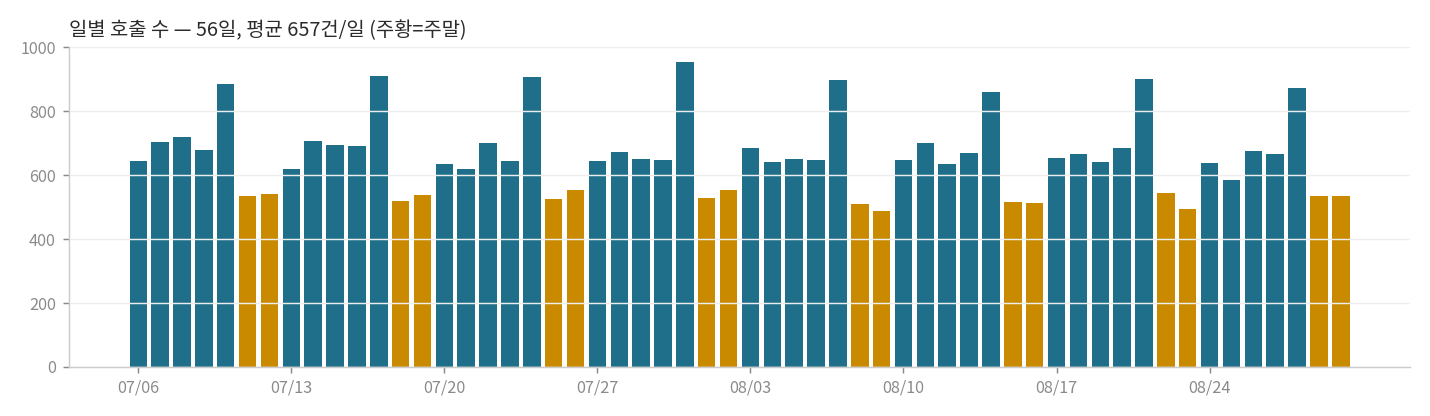

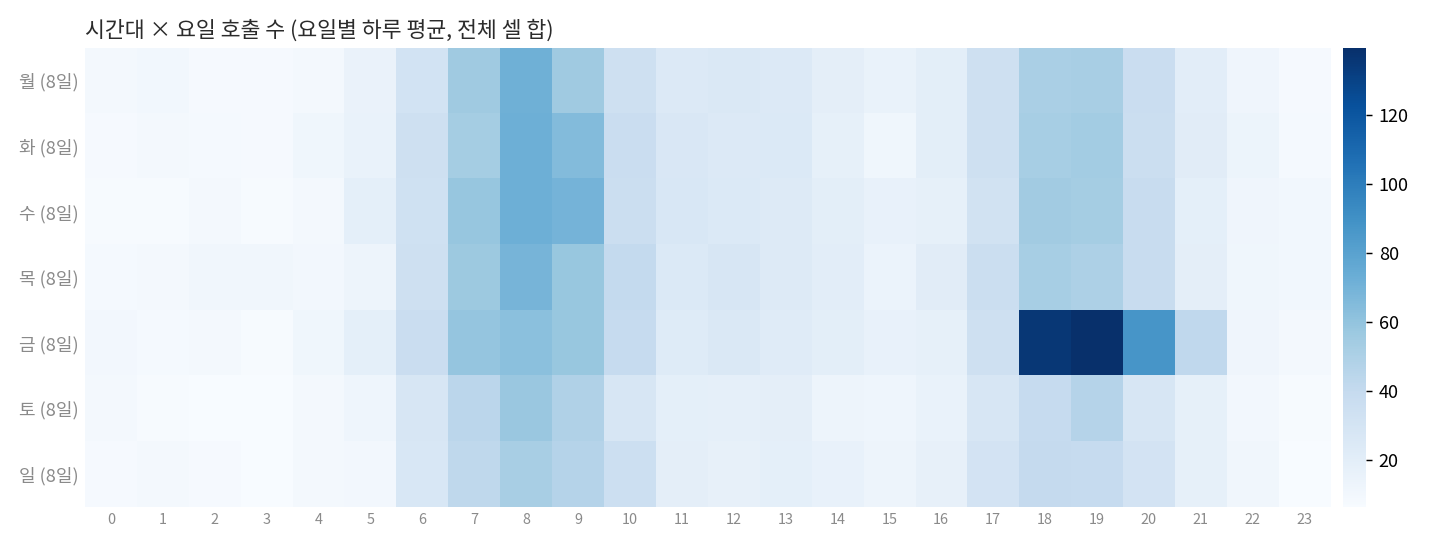

In [ ]:
from IPython.display import Image, display
display(Image('../data/eda/8w/01_daily.png')); display(Image('../data/eda/8w/02_hour_dow_heatmap.png'))

- 하루 평균 657건. 금요일 899건으로 다른 평일(646~672)보다 35% 많고, 주말 527건으로 평일 대비 −26%.
- 피크는 8시(등교·출근)와 18~19시(퇴근·저녁). 금요일 18~20시가 전체에서 가장 진한 칸 — "강남역 금요일 저녁" 시나리오가 데이터에 재현됨(이벤트 셀 ×3).
- 요일별 8일씩 관측되어 요일 효과를 평균과 변동으로 추정할 수 있다 (1일치에서는 불가했던 것).

## 2. 공간 패턴 — 셀마다 피크가 다르다

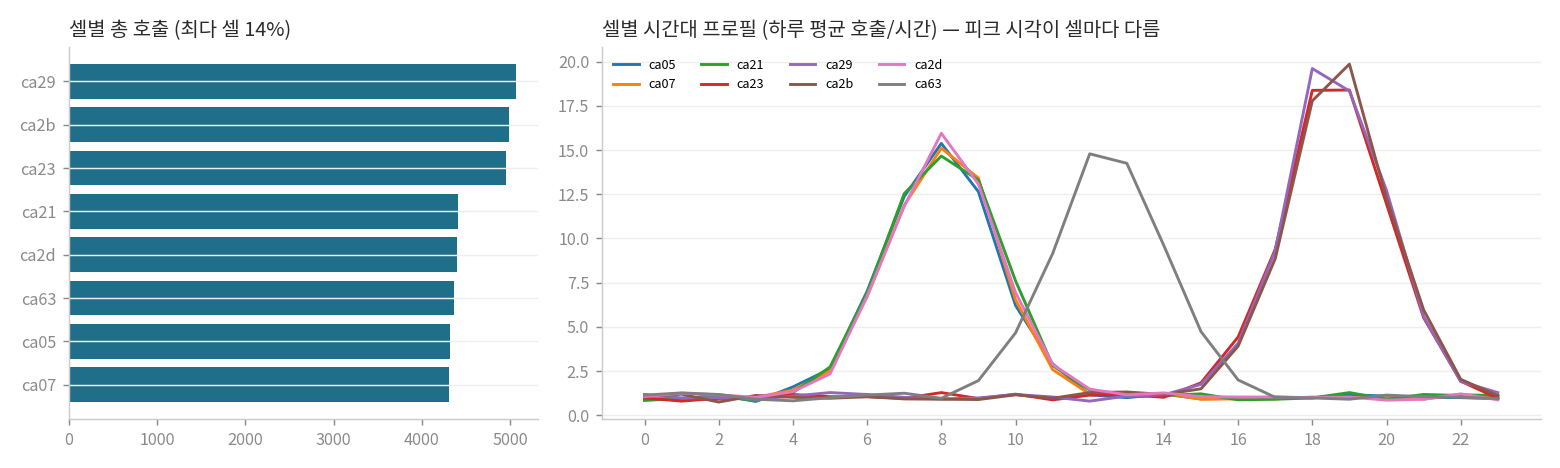

In [ ]:
display(Image('../data/eda/8w/03_cell_profiles.png'))

- 셀 8개(res 8)의 총량은 11.7~13.8%로 고르지만 **피크 시각이 다르다**: 4개 셀은 8시, 3개 셀은 18~19시, 1개 셀은 12시. 이게 격자별로 따로 학습해야 하는 이유이고, `same_time_*` 피처가 셀별로 계산되는 이유.
- H3 해상도: EDA(1일치)에서는 res 9가 더 세밀했으나 지도·배차 모듈과 셀 목록을 맞추기 위해 팀 기준 res 8을 쓴다. res 비교 재실행은 `python eda/h3_resolution_compare.py`.

## 3. 평일 / 주말 / 공휴일

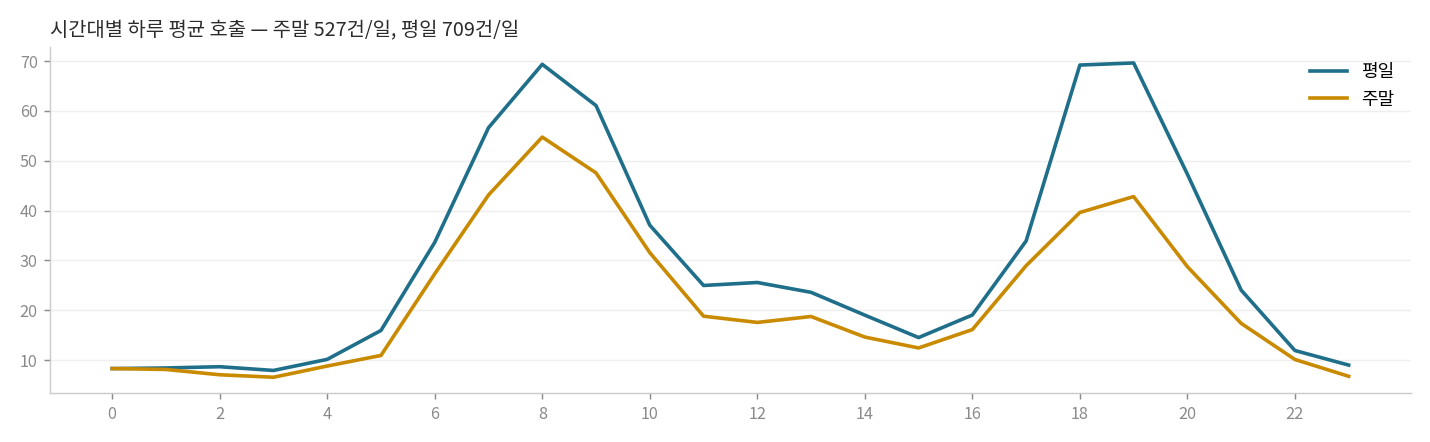

In [ ]:
display(Image('../data/eda/8w/04_weekday_holiday.png'))

- 주말은 아침 피크가 사라지고 저녁만 남는다(×0.8 배수 + 출근 수요 없음).
- 기간 내 평일 공휴일이 없다(8/15 광복절이 토요일). 따라서 `is_public_holiday`·연휴 피처는 이 데이터에서 주말과 구분되지 않는다 — 생성기가 대체공휴일(8/17)을 달력으로 넣으면 분리 가능.

## 4. 날씨 — 수요는 올리지만 예측에는 못 쓴다

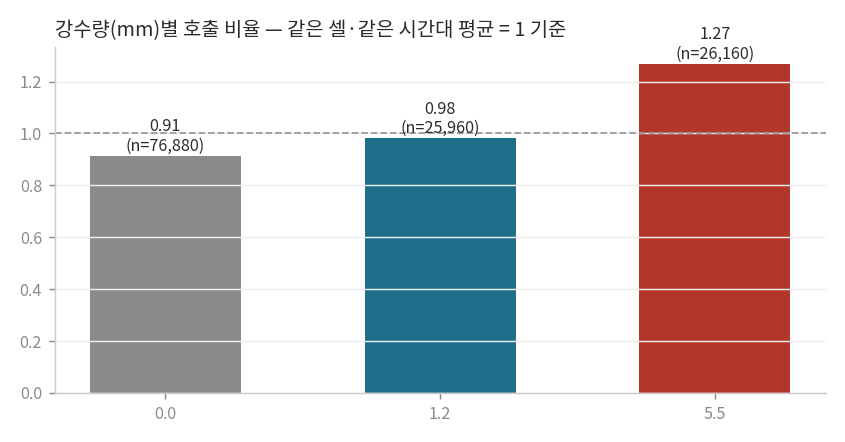

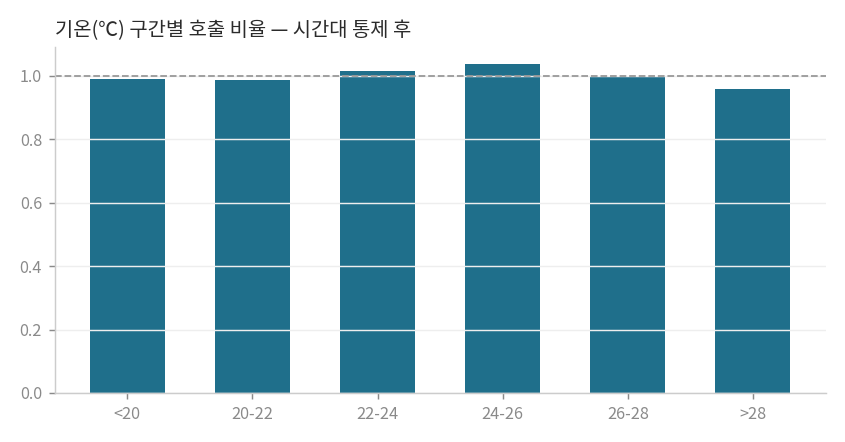

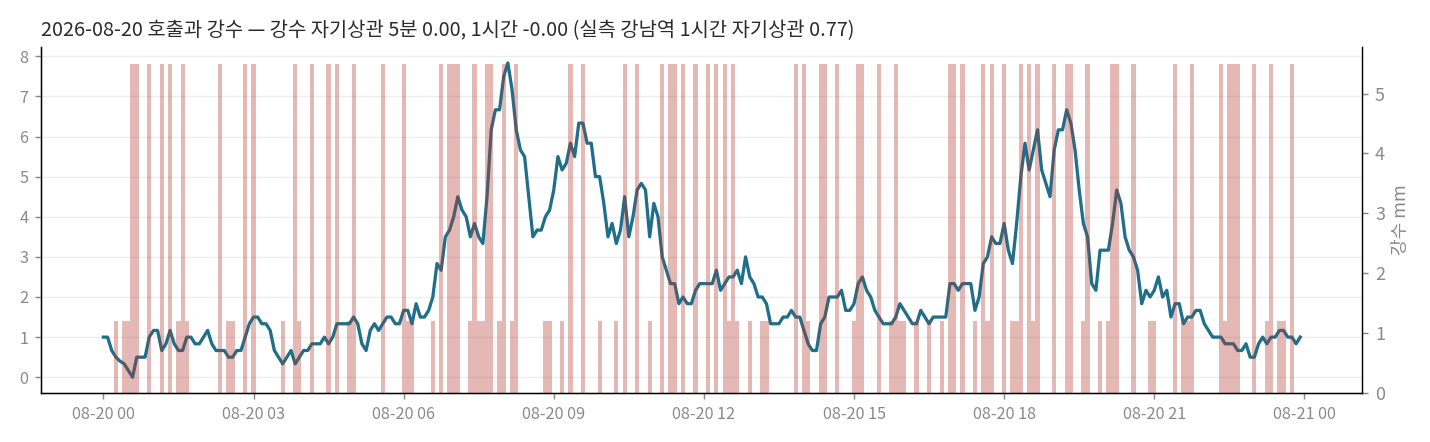

In [ ]:
display(Image('../data/eda/8w/05_weather_rain.png')); display(Image('../data/eda/8w/06_weather_temp.png')); display(Image('../data/eda/8w/07_rain_day.png'))

- 같은 셀·같은 시간대 평균을 1로 두면 강수 0mm 0.92, 1.2mm 0.98, 5.5mm **1.27** — 비가 많이 올수록 호출이 는다(생성기 배수 1+0.08×mm와 일치).
- 기온은 0.96~1.04로 효과가 거의 없다(생성기가 기온을 수요에 넣지 않음; 매일 같은 사인 곡선이라 시간대와 겹침).
- **강수 자기상관 5분 0.002, 1시간 −0.003** (실측 강남역 1시간 0.77). 지금 비가 오는지가 5분 뒤 비와 무관하므로, 과거만 쓰는 모델은 미래 강수 효과를 학습할 수 없다. 8주 ablation에서 날씨 피처 기여가 0인 이유. → 생성기 개선 제안(강수 에피소드 지속, 실측 계수)은 `docs/module2_weather_holiday_strict.md` 3절.

## 5. 정상성 — 8주에서는 원계열도 정상

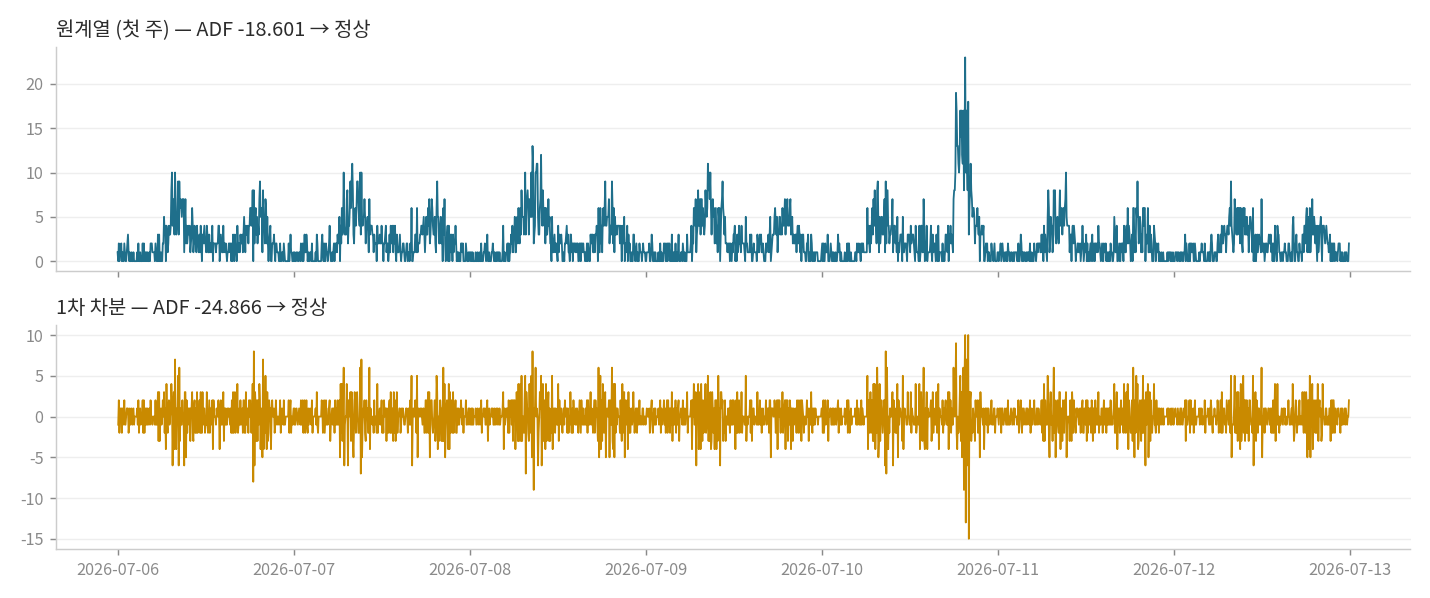

In [ ]:
display(Image('../data/eda/8w/08_stationarity.png'))

- ADF 통계량 원계열 −18.6, 1차 차분 −24.9 (1% 임계값 −3.43) → 둘 다 단위근 없음. 1일치(09~11시)에서는 원계열이 비정상(p=0.73)이었는데, 그건 2시간 창 안의 출근 상승 추세였고 8주 전체로 보면 수요는 일 주기 주변에서 정상적으로 흔들린다.
- 의미: 차분이 필수는 아니지만 일 주기·주 주기가 강하므로 `same_time_yesterday`/`same_time_last_week` 같은 계절 피처와 `diff_1`(단기 추세)이 함께 필요하다. ARIMA 계열과 비교한다면 d=0 + 계절 항(SARIMA)이 자연스럽다.

## 6. 자기상관 — lag 피처의 근거

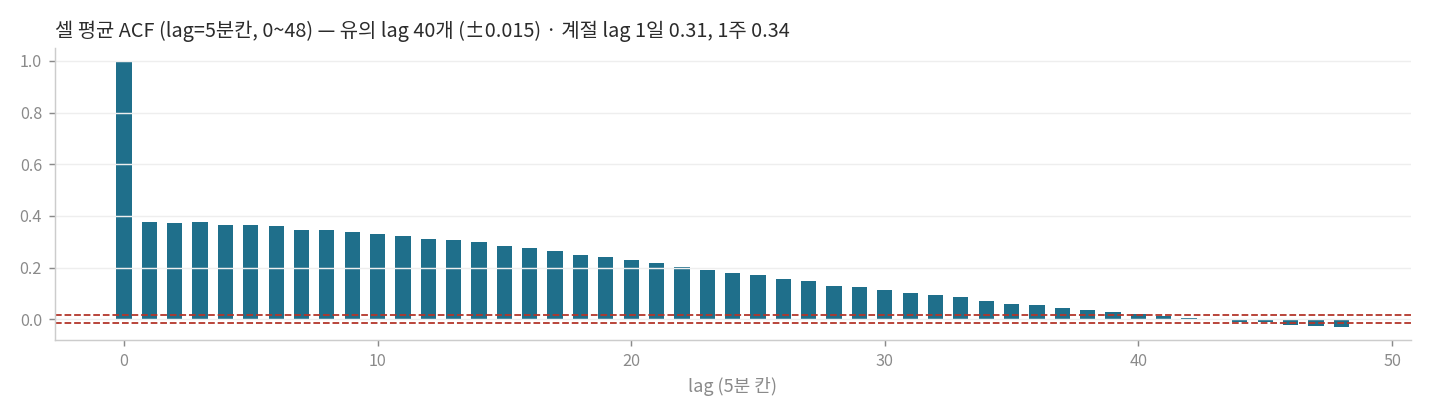

In [ ]:
display(Image('../data/eda/8w/09_acf.png'))

- 셀 평균 ACF: lag1 0.38, lag6(30분) 0.36, lag12(1시간) 0.31, 유의 lag 40개(±0.015). 1일치의 "판정 불가"가 8주에서는 "40칸까지 유의"로 바뀌었다.
- 계절 lag: 1일 전 0.31, 1주 전 0.34 — 어제·지난주 동일칸 피처가 lag1과 비슷한 정보량을 갖는다.
- lag 6개 + rolling 1h(12칸)는 유의 구간 안에 있고, 그 이상은 rolling과 계절 피처가 대신한다.

## 7. 피처 유효성 — ablation (같은 데이터, 시간순 뒤 20% test)

`python scripts/feature_ablation.py data/generated/calls.csv --external data/generated/external.csv` 결과(`data/eda/feature_ablation_8w_synthetic.md`):

| 피처 그룹 (누적) | 피처 수 | MAE | RMSE | WAPE | 기존 34 대비 MAE |
|---|---:|---:|---:|---:|---:|
| 전부 0 예측 | 1 | 0.2816 | 0.7454 | 100.0% | |
| 나이브 (직전 5분 값 유지) | 1 | 0.3558 | 0.7662 | 126.4% | |
| lag 1~6 | 6 | 0.3443 | 0.5874 | 122.3% | +7.8% |
| + rolling/std/diff/지난주 | 13 | 0.3340 | 0.5758 | 118.6% | +4.5% |
| + 달력 기본 15 | 28 | 0.3195 | 0.5468 | 113.5% | +0.0% |
| + 날씨 기본 6 [= 기존 34] | 34 | 0.3195 | 0.5468 | 113.5% | — |
| + 휴일 강화 4 | 38 | 0.3193 | 0.5464 | 113.4% | −0.1% |
| + 날씨 파생 3 | 41 | 0.3195 | 0.5465 | 113.5% | −0.0% |
| + 어제 동일칸 2 [= 43] | 43 | 0.3186 | 0.5460 | 113.1% | −0.3% |

- 나이브 대비 RMSE −29%. 타깃의 80%가 0이라 MAE는 "전부 0"이 가장 낮게 나오므로 RMSE·WAPE로 비교한다.
- 기여 순서: 달력 > rolling/지난주 > lag > 어제 동일칸(작지만 일관). 휴일 강화·날씨 파생은 4절·3절의 데이터 한계로 0.